This notebook generates the plots used in figure X of the report. All relevant data is generated by other code in this repository

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Defining plotting functions

In [35]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''

    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots(figsize = (10, 7))
    
    sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'], inner = 'box', ax = ax)
    ax.tick_params(axis='both', which='major', labelsize=15)
    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 20)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 20)
    elif y_col == 'PCC':
        ax.set_ylabel('PCC', fontsize = 20)
    elif y_col == 'SPC':
        ax.set_ylabel('SPC', fontsize = 20)
    ax.set_xlabel('Dataset', fontsize = 20)
   
    plt.ylim(plot_kwargs['ylim'])
    
    fig.suptitle(title, fontsize = 25)

    ax.tick_params(axis='both', which='major', labelsize=15)

    plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [8]:
#define palette for train, test, male and female samples that will be used across the dataset
palette = {'Train': '#4b4ba3', 'Test' : '#248af0', 'Male': '#C1121F', 'Female': '#FDF1D7'}

## Genewise Pearsons Loss in Deep Learning Model across Train, Test, Male External, Female External

In [9]:
DATA_ROOT = '../data'

In [10]:
#load train and test loss function values generated during training
train_test_scores = pd.read_csv(f'{DATA_ROOT}/log_norm_results.csv', index_col = 0)

#transform loss into PCC and name column desired X labels of violin plot
train_test_scores['train_PCC'] = 1 - train_test_scores['train_loss']
train_test_scores['test_PCC'] = 1 - train_test_scores['test_loss']

In [11]:
#load PCC from external male and female samples (do not need to transform these)
MF_scores = pd.read_csv(f'{DATA_ROOT}/female_male_PCC_norm.csv', index_col = 0)

#get only TGs with better than 80% correlation in male and females
MF_scores[(MF_scores['female_PCC'] > 0.7) & (MF_scores['male_PCC'] > 0.7)]

,female_PCC,male_PCC,female_SPC,male_SPC
A2M,0.796548,0.733337,NaN,NaN
AAAS,0.881399,0.885336,NaN,NaN
AACS,0.828041,0.789277,NaN,NaN
AAGAB,0.927280,0.937232,NaN,NaN
AAK1,0.887892,0.893452,NaN,NaN
...,...,...,...,...
ZXDB,0.806064,0.845817,NaN,NaN
ZXDC,0.910356,0.874428,NaN,NaN
ZYG11B,0.823110,0.848007,NaN,NaN
ZZEF1,0.906332,0.890341,NaN,NaN


In [12]:
#create a plotting dataframe that will be melted for use with create_pearsons_violin, columns are named for X axis ticks
plot_frame = pd.DataFrame(index = MF_scores.index, columns = ['Train', 'Test', 'Female', 'Male'])
plot_frame['Train'] = train_test_scores['train_PCC']
plot_frame['Test'] = train_test_scores['test_PCC']
plot_frame['Female'] = MF_scores['female_PCC']
plot_frame['Male'] = MF_scores['male_PCC']

#melt df so compatible with plotting functions
plot_frame = plot_frame.melt()
plot_frame.columns = ['dataset', 'PCC']

In [19]:
plot_frame[(plot_frame['dataset'] == 'Train') | (plot_frame['dataset'] == 'Test')]

,dataset,PCC
0,Train,0.847483
1,Train,0.734361
2,Train,0.860702
3,Train,0.911879
4,Train,0.924782
...,...,...
30393,Test,0.866582
30394,Test,0.940480
30395,Test,0.884315
30396,Test,0.953747


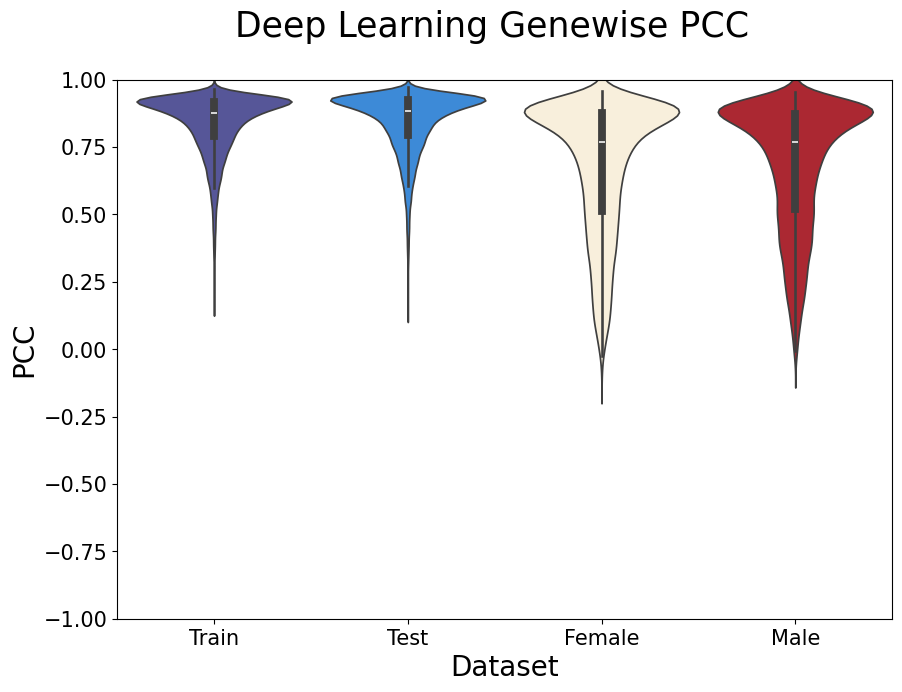

In [23]:
create_pearsons_violin(plot_frame, y_col = 'PCC', title = 'Deep Learning Genewise PCC', file_title = 'DL_genewise_PCC', palette = palette)

In [21]:
# Male and Female only plot for the presentation
plot_frame_MF = plot_frame[(plot_frame['dataset'] == 'Male') |  (plot_frame['dataset'] == 'Female')]
plot_frame_MF

,dataset,PCC
30398,Female,0.796548
30399,Female,0.123123
30400,Female,0.535818
30401,Female,0.881399
30402,Female,0.828041
...,...,...
60791,Male,0.607923
60792,Male,0.848007
60793,Male,0.648326
60794,Male,0.890341


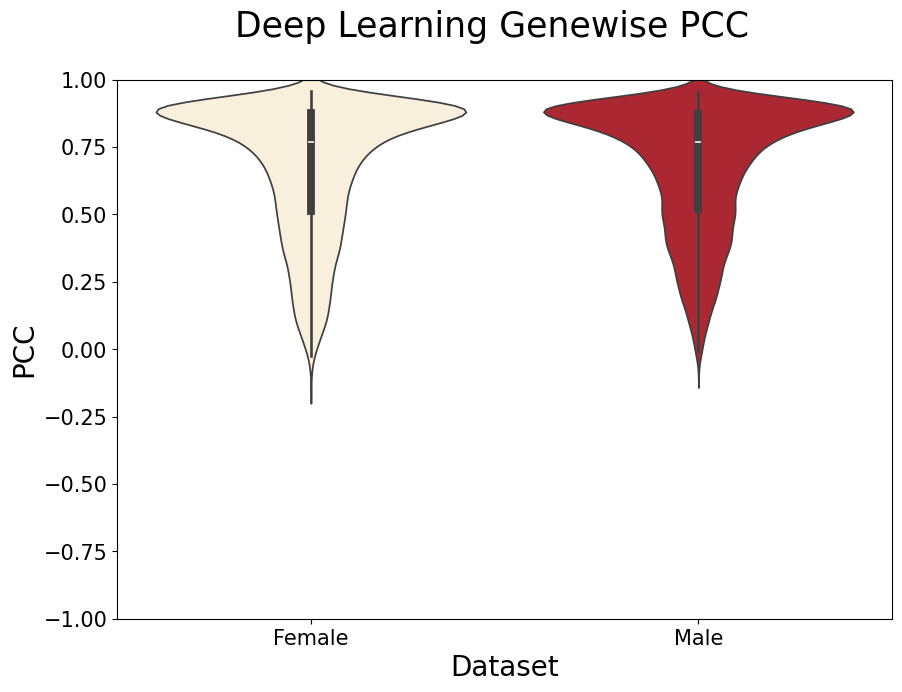

In [22]:
create_pearsons_violin(plot_frame_MF, y_col = 'PCC', title = 'Deep Learning Genewise PCC', file_title = 'DL_genewise_PCC_MF', palette = palette)

# Genewise in MLR and RF

In [25]:
RF_results = pd.read_csv('../RF_MLR/data/RF_regressor_results_norm.csv', index_col = 0)
#RF_results.columns = ['Train', 'Test', 'Male', 'Female']

In [33]:
RF_results_spearmans = RF_results[['train_SP', 'test_SP', 'male_SP', 'female_SP']]
RF_results_spearmans.columns = ['Train', 'Test', 'Male', 'Female']
RF_results_spearmans = RF_results_spearmans.melt()
RF_results_spearmans.columns = ['dataset', 'SPC']

In [ ]:
RF_results_pearsons = RF_results[['train_PCC', 'test_PCC', 'male_PCC', 'female_PCC']]
RF_results_pearsons.columns = ['Train', 'Test', 'Male', 'Female']
RF_results_pearsons = RF_results_pearsons.melt()
RF_results_pearsons.columns = ['dataset', 'PCC']

In [ ]:
RF_results_to_plot = RF_results.melt()
RF_results_to_plot.columns = ['dataset', 'PCC']

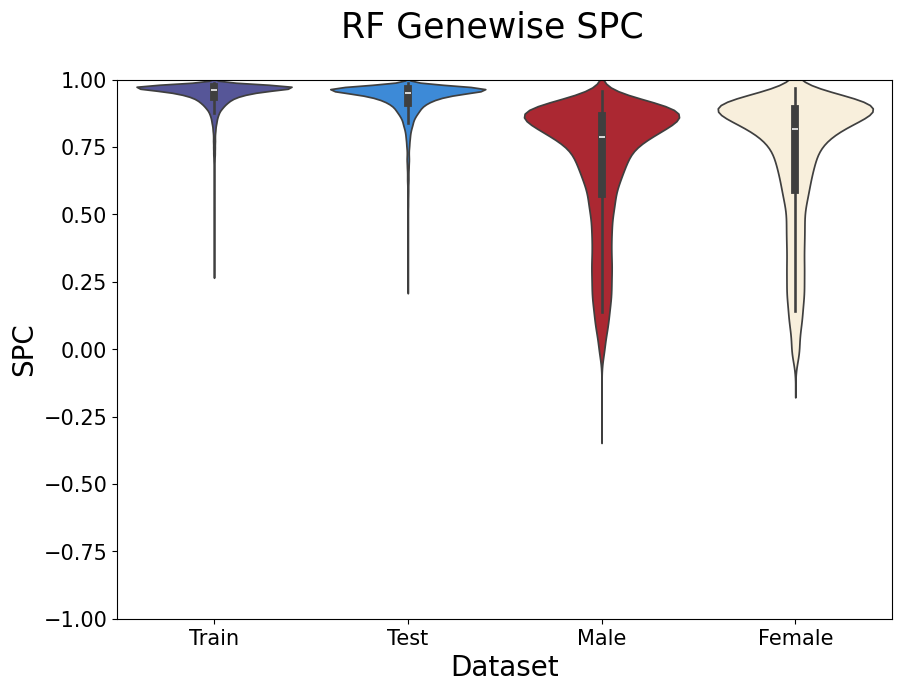

In [46]:
create_pearsons_violin(RF_results_spearmans, y_col = 'SPC', title = 'RF Genewise SPC', file_title = 'RF_genewise_SPC', palette = palette)

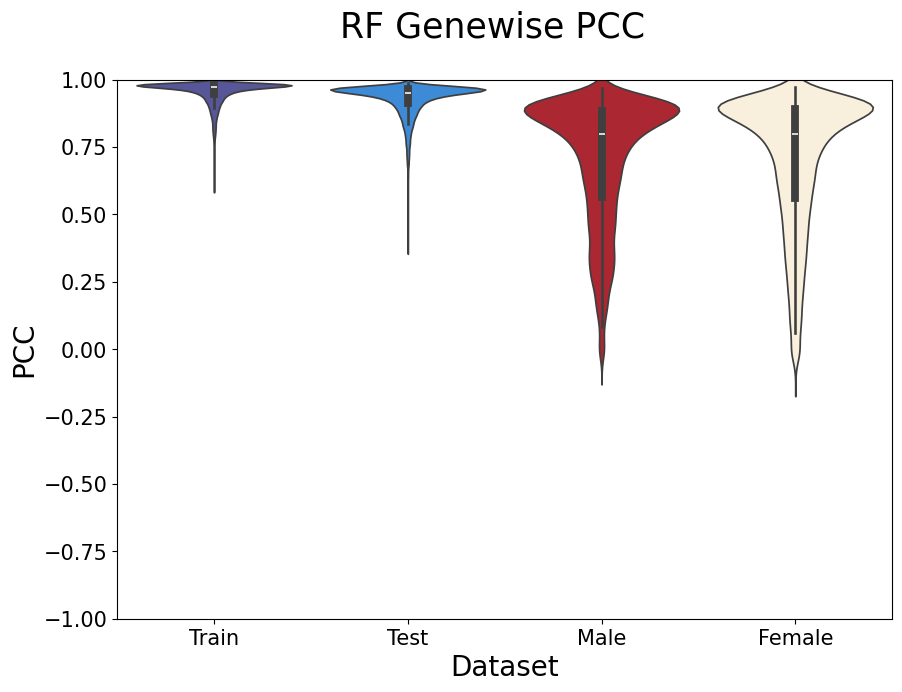

In [37]:
create_pearsons_violin(RF_results_pearsons, y_col = 'PCC', title = 'RF Genewise PCC', file_title = 'RF_genewise_PCC', palette = palette)

## MLR

In [38]:
MLR_results = pd.read_csv('../RF_MLR/data/MLR_regressor_results.csv', index_col = 0)
MLR_results_spearmans = MLR_results[['train_SP', 'test_SP', 'male_SP', 'female_SP']]
MLR_results_spearmans.columns = ['Train', 'Test', 'Male', 'Female']
MLR_results_spearmans = MLR_results_spearmans.melt()
MLR_results_spearmans.columns = ['dataset', 'SPC']

In [42]:
MLR_results_pearsons = RF_results[['train_PCC', 'test_PCC', 'male_PCC', 'female_PCC']]
MLR_results_pearsons.columns = ['Train', 'Test', 'Male', 'Female']
MLR_results_pearsons = MLR_results_pearsons.melt()
MLR_results_pearsons.columns = ['dataset', 'PCC']

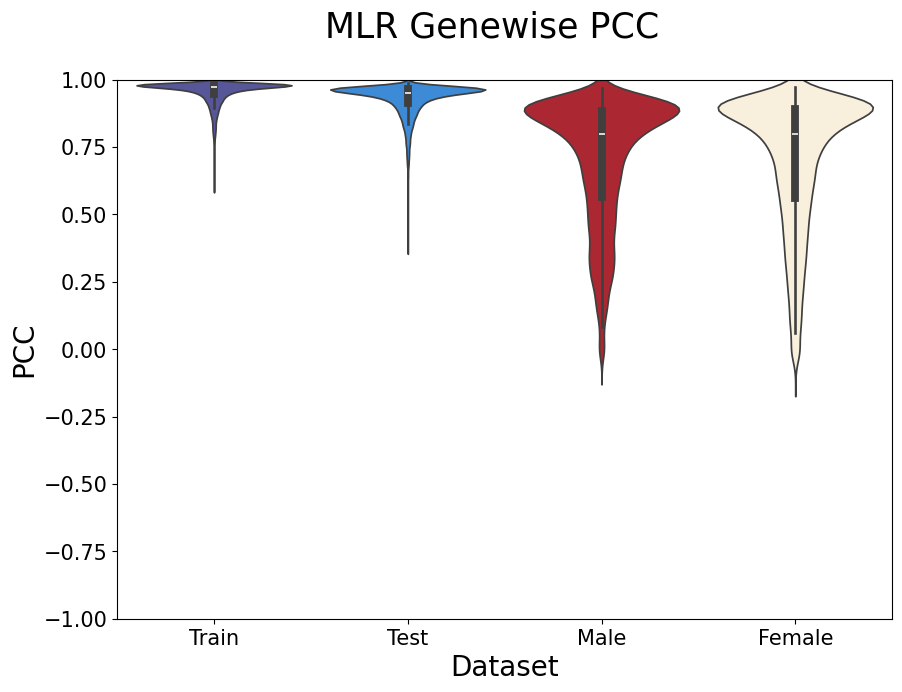

In [ ]:
create_pearsons_violin(MLR_results_pearsons, y_col = 'PCC', title = 'MLR Genewise PCC', file_title = 'MLR_genewise_PCC', palette = palette)

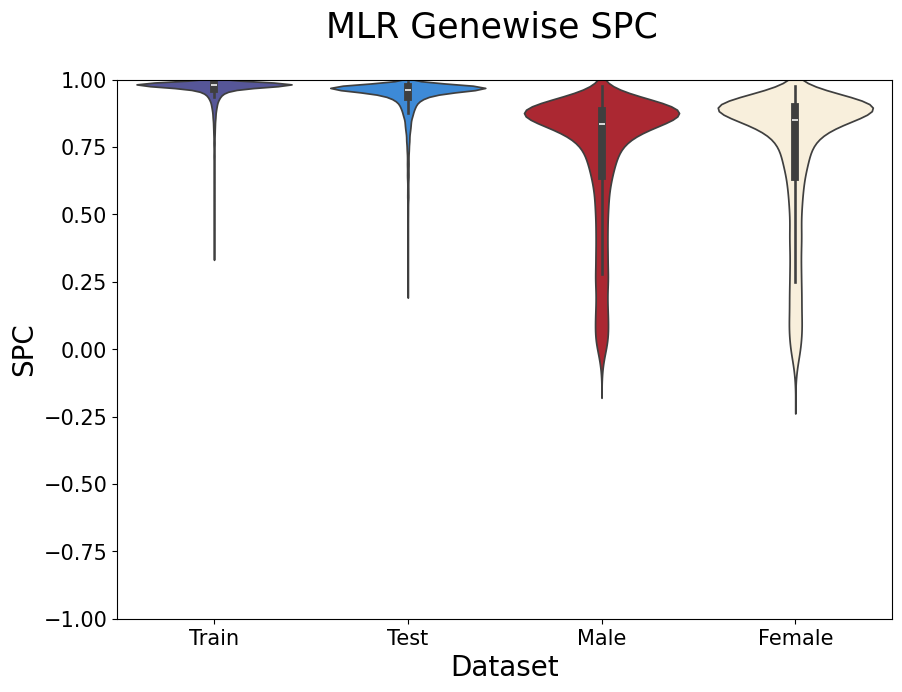

In [44]:
create_pearsons_violin(MLR_results_spearmans, y_col = 'SPC', title = 'MLR Genewise SPC', file_title = 'MLR_genewise_SPC', palette = palette)